In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

import xgboost as xgb
import lightgbm as lgb

sns.set(style="whitegrid")
BASE_DIR = r"E:\Research\Paper_A_XAI_IDS"
PROCESSED_DIR = os.path.join(BASE_DIR, "02_Data", "processed")
RESULTS_DIR = os.path.join(BASE_DIR, "04_Results", "metrics")
FIG_DIR = os.path.join(BASE_DIR, "05_Figures", "raw")
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

In [2]:
X_train = pd.read_csv(os.path.join(PROCESSED_DIR, "X_train_final.csv"))
X_val = pd.read_csv(os.path.join(PROCESSED_DIR, "X_val_final.csv"))
X_test = pd.read_csv(os.path.join(PROCESSED_DIR, "X_test_final.csv"))

y_train = pd.read_csv(os.path.join(PROCESSED_DIR, "y_train_binary.csv")).squeeze("columns")
y_val = pd.read_csv(os.path.join(PROCESSED_DIR, "y_val_binary.csv")).squeeze("columns")
y_test = pd.read_csv(os.path.join(PROCESSED_DIR, "y_test_binary.csv")).squeeze("columns")

print(X_train.shape, X_val.shape, X_test.shape)
print(y_train.shape, y_val.shape, y_test.shape)

(100778, 122) (25195, 122) (22544, 122)
(100778,) (25195,) (22544,)


In [3]:
print(y_train.value_counts(normalize=True))
print(y_val.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

binary_label
0    0.534581
1    0.465419
Name: proportion, dtype: float64
binary_label
0    0.53459
1    0.46541
Name: proportion, dtype: float64
binary_label
1    0.569242
0    0.430758
Name: proportion, dtype: float64


In [4]:
def evaluate_model(name, model, Xtr, ytr, Xva, yva):
    model.fit(Xtr, ytr)
    pred = model.predict(Xva)
    results = {
        "model": name,
        "accuracy": accuracy_score(yva, pred),
        "precision": precision_score(yva, pred, zero_division=0),
        "recall": recall_score(yva, pred, zero_division=0),
        "f1": f1_score(yva, pred, zero_division=0),
    }
    if hasattr(model, "predict_proba"):
        try:
            proba = model.predict_proba(Xva)[:, 1]
            results["roc_auc"] = roc_auc_score(yva, proba)
        except Exception:
            results["roc_auc"] = np.nan
    else:
        results["roc_auc"] = np.nan
    return model, pred, results

In [5]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=200, n_jobs=None),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric="logloss", random_state=42, n_jobs=-1
    ),
    "LightGBM": lgb.LGBMClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=-1,
        random_state=42, n_jobs=-1
    )
}

In [6]:
results = []
trained_models = {}
predictions = {}

for name, model in models.items():
    print(f"Training {name}...")
    trained, pred, res = evaluate_model(name, model, X_train, y_train, X_val, y_val)
    trained_models[name] = trained
    predictions[name] = pred
    results.append(res)

results_df = pd.DataFrame(results).sort_values(by="f1", ascending=False)
results_df

Training LogisticRegression...
Training RandomForest...
Training XGBoost...
Training LightGBM...
[LightGBM] [Info] Number of positive: 46904, number of negative: 53874
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.126753 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3262
[LightGBM] [Info] Number of data points in the train set: 100778, number of used features: 110
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.465419 -> initscore=-0.138545
[LightGBM] [Info] Start training from score -0.138545


,model,accuracy,precision,recall,f1,roc_auc
3,LightGBM,0.999405,0.999488,0.999232,0.999360,0.999997
2,XGBoost,0.999365,0.999403,0.999232,0.999318,0.999992
1,RandomForest,0.999087,0.999488,0.998550,0.999019,0.999995
0,LogisticRegression,0.880492,0.894808,0.842231,0.867724,0.949960


In [7]:
results_path = os.path.join(RESULTS_DIR, "baseline_validation_results.csv")
results_df.to_csv(results_path, index=False)
print("Saved:", results_path)

Saved: E:\Research\Paper_A_XAI_IDS\04_Results\metrics\baseline_validation_results.csv


In [8]:
results_df

,model,accuracy,precision,recall,f1,roc_auc
3,LightGBM,0.999405,0.999488,0.999232,0.999360,0.999997
2,XGBoost,0.999365,0.999403,0.999232,0.999318,0.999992
1,RandomForest,0.999087,0.999488,0.998550,0.999019,0.999995
0,LogisticRegression,0.880492,0.894808,0.842231,0.867724,0.949960


In [9]:
best_model_name = results_df.iloc[0]["model"]
best_model = trained_models[best_model_name]
print("Best model:", best_model_name)

Best model: LightGBM


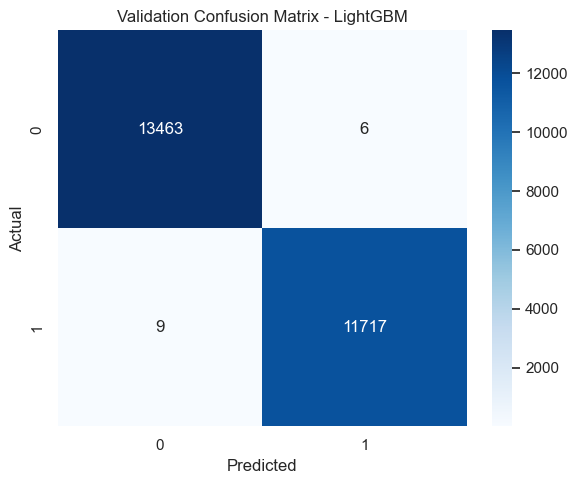

Saved: E:\Research\Paper_A_XAI_IDS\05_Figures\raw\validation_confusion_matrix_best_model.png


In [10]:
val_pred = best_model.predict(X_val)
cm = confusion_matrix(y_val, val_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Validation Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()

cm_path = os.path.join(FIG_DIR, "validation_confusion_matrix_best_model.png")
plt.savefig(cm_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", cm_path)

In [11]:
print(classification_report(y_val, val_pred, zero_division=0))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13469
           1       1.00      1.00      1.00     11726

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195



In [12]:
final_pred = best_model.predict(X_test)

final_results = {
    "model": best_model_name,
    "test_accuracy": accuracy_score(y_test, final_pred),
    "test_precision": precision_score(y_test, final_pred, zero_division=0),
    "test_recall": recall_score(y_test, final_pred, zero_division=0),
    "test_f1": f1_score(y_test, final_pred, zero_division=0),
}

if hasattr(best_model, "predict_proba"):
    try:
        final_results["test_roc_auc"] = roc_auc_score(y_test, best_model.predict_proba(X_test)[:, 1])
    except Exception:
        final_results["test_roc_auc"] = np.nan
else:
    final_results["test_roc_auc"] = np.nan

final_results_df = pd.DataFrame([final_results])
final_results_df

,model,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,LightGBM,0.775772,0.967428,0.627211,0.761027,0.96331


In [13]:
final_path = os.path.join(RESULTS_DIR, "best_model_test_results.csv")
final_results_df.to_csv(final_path, index=False)
print("Saved:", final_path)

Saved: E:\Research\Paper_A_XAI_IDS\04_Results\metrics\best_model_test_results.csv


In [14]:
comparison = results_df[["model", "accuracy", "precision", "recall", "f1", "roc_auc"]].copy()
comparison

,model,accuracy,precision,recall,f1,roc_auc
3,LightGBM,0.999405,0.999488,0.999232,0.999360,0.999997
2,XGBoost,0.999365,0.999403,0.999232,0.999318,0.999992
1,RandomForest,0.999087,0.999488,0.998550,0.999019,0.999995
0,LogisticRegression,0.880492,0.894808,0.842231,0.867724,0.949960


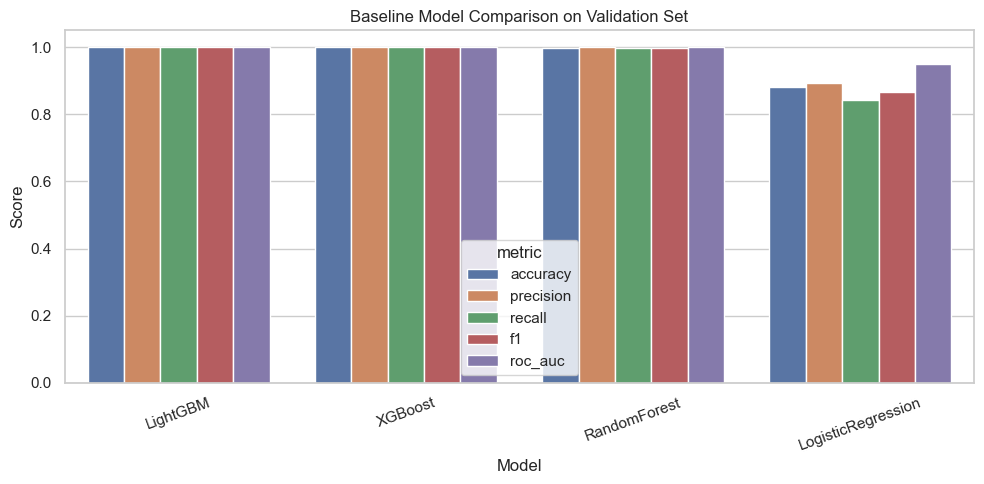

Saved: E:\Research\Paper_A_XAI_IDS\05_Figures\raw\baseline_model_comparison.png


In [15]:
plt.figure(figsize=(10,5))
comparison_melt = comparison.melt(id_vars="model", var_name="metric", value_name="score")
sns.barplot(data=comparison_melt, x="model", y="score", hue="metric")
plt.title("Baseline Model Comparison on Validation Set")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.tight_layout()

cmp_path = os.path.join(FIG_DIR, "baseline_model_comparison.png")
plt.savefig(cmp_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", cmp_path)

In [16]:
print("Baseline modeling complete.")
print("Next step: explainability notebook named 04_nsl_kdd_explainability.ipynb")

Baseline modeling complete.
Next step: explainability notebook named 04_nsl_kdd_explainability.ipynb
